In [1]:
!pip install -q rasterio pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 1.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from kan import KAN
import torch.optim as optim

In [8]:
# 1. Configurar dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executando em: {device}")

# 2. Lendo imagem como array (Seu código original)
src = rio.open('/content/drive/MyDrive/Curso PDI com Python/L71221071_07120010720_DN.tif')
b1 = src.read(1)
b2 = src.read(2)
b3 = src.read(3)
b4 = src.read(4)
b5 = src.read(5)
b7 = src.read(6)

img = np.dstack([b1, b2, b3, b4, b5, b7])
meta = src.profile

# 3. Lendo ROI/Classes (Seu código original)
with rio.open('/content/drive/MyDrive/Curso PDI com Python/roi.tif') as src2:
    roi = src2.read(1)

# 4. Criando conjunto de treino onde roi > 0
X = img[roi > 0]
y = roi[roi > 0]

classes_originais = np.unique(y)
n_classes = len(classes_originais)
mapping = {at: i for i, at in enumerate(classes_originais)}
y_mapped = np.array([mapping[val] for i, val in enumerate(y)])

# 5. Normalização dos dados (Obrigatório para KAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Dividindo conjunto em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_mapped, test_size=0.3, random_state=42)

# 7. Preparando o dicionário de dados para a PyKAN (PyTorch Tensors)
dataset = {
    'train_input': torch.tensor(X_train, dtype=torch.float32).to(device),
    'train_label': torch.tensor(y_train, dtype=torch.long).to(device),
    'test_input': torch.tensor(X_test, dtype=torch.float32).to(device),
    'test_label': torch.tensor(y_test, dtype=torch.long).to(device)
}

# 8. Instanciando a KAN
# Arquitetura: [6 bandas de entrada -> 5 neurônios ocultos -> N classes de saída]
model = KAN(width=[6, 5, n_classes], grid=3, k=3, device=device)

# Mapeadores de acurácia para o treinamento
def train_acc():
    return torch.mean((torch.argmax(model(dataset['train_input']), dim=1) == dataset['train_label']).float()).item()

def test_acc():
    return torch.mean((torch.argmax(model(dataset['test_input']), dim=1) == dataset['test_label']).float()).item()


Executando em: cpu
checkpoint directory created: ./model
saving model version 0.0


In [ ]:
# 9. Treinamento Nativo em PyTorch (Substitui o model.train antigo)
model.train()

# Usaremos o otimizador Adam, que é extremamente estável para classificação de pixels
optimizer = optim.Adam(model.parameters(), lr=0.02)
loss_fn = torch.nn.CrossEntropyLoss()

epochs = 40  # Número de épocas de treinamento

for epoch in range(epochs):
    # Zera os gradientes do passo anterior
    optimizer.zero_grad()

    # Forward: Passa os dados de treino pela KAN
    outputs = model(dataset['train_input'])
    loss = loss_fn(outputs, dataset['train_label'])

    # Backward: Calcula os gradientes e atualiza os pesos
    loss.backward()
    optimizer.step()

    # Monitoramento do treino a cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        with torch.no_grad():
            # Calcula acurácia de treino
            train_preds = torch.argmax(outputs, dim=1)
            train_accuracy = torch.mean((train_preds == dataset['train_label']).float()).item()

            # Calcula acurácia de teste
            test_outputs = model(dataset['test_input'])
            test_preds = torch.argmax(test_outputs, dim=1)
            test_accuracy = torch.mean((test_preds == dataset['test_label']).float()).item()

        print(f"Época {epoch+1:02d}/{epochs} | Perda (Loss): {loss.item():.4f} | Acurácia Treino: {train_accuracy:.4f} | Acurácia Teste: {test_accuracy:.4f}")


# 10. Classificação de toda a imagem (Predição)
# Criando matriz com bandas em colunas e aplicando o mesmo scaler
img2d = img.reshape(img.shape[0] * img.shape[1], img.shape[2])
img2d_scaled = scaler.transform(img2d)

# Convertendo a imagem inteira para tensor e rodando na GPU/CPU
img_tensor = torch.tensor(img2d_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    pred_kan_tensor = torch.argmax(model(img_tensor), dim=1)
    pred_kan = pred_kan_tensor.cpu().numpy()

# Desfazendo o mapeamento de classes para voltar aos valores originais do seu ROI
inv_mapping = {i: at for i, at in enumerate(classes_originais)}
pred_kan_original_labels = np.array([inv_mapping[val] for val in pred_kan])

# Retornando para o formato original da imagem (matriz 2D)
pred_kan_final = pred_kan_original_labels.reshape(img[:,:,0].shape)


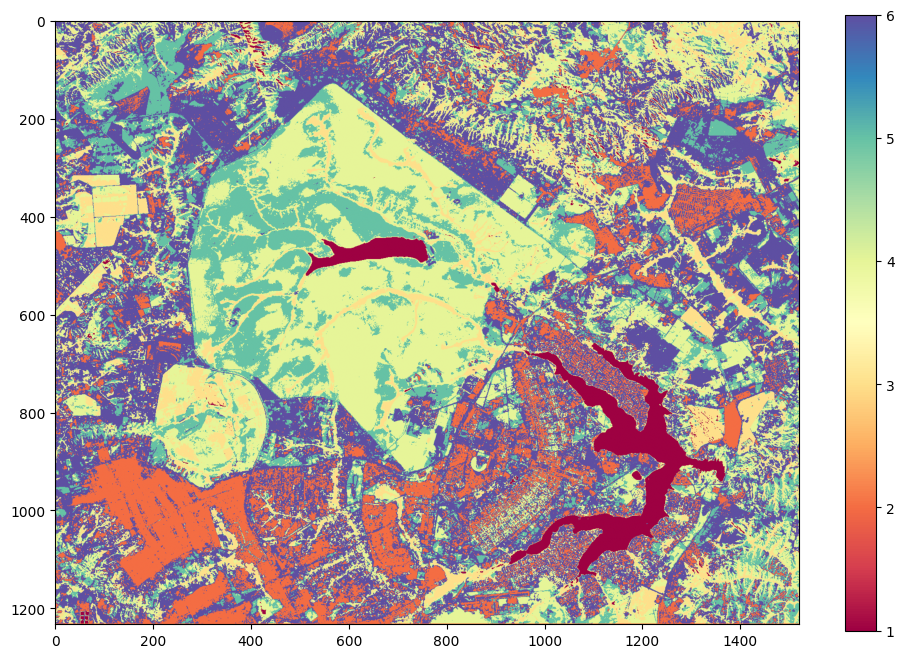

In [9]:
# 11. Visualizando o resultado
plt.figure(figsize=(12, 8))
plt.imshow(pred_kan_final, cmap='Spectral')
plt.colorbar()
plt.show()